# Property values breakdown into land and structure

I hypothesize that property value tends to turn into land value over time, because the structure on top depreciates. Show how much this is true,
by fetching assessor data, normalizing to constant dollars, and comparing how the assessor's values have trended over time for the typical property.

We track a stable **cohort** of residential parcels (`USE_CODE < 200`, excluding 130-140) that appear in every assessment snapshot from 2011 to 2026.
All dollar values are expressed in constant 2026 dollars (2.5% annual inflation).

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from investigations.land_values import fetch

%matplotlib inline

# Fetch data

Data for this analysis comes from MassGIS, which should be coming from Waltham's assessor. Only non-condo residential properties are included, since condos do not include land value in property valuations.

In [12]:
df = fetch.fetch_cohort_data()
# filter out structures where land values are 0 (i.e. condos)
df = df[df["LAND_VAL"] > 0]

print(f"Cohort: {df['PROP_ID'].nunique():,} parcels x {df['assessed_year'].nunique()} years = {len(df):,} rows")

Cohort: 10,895 parcels x 13 years = 141,634 rows


In [13]:
df["land_share"] = df["LAND_VAL"] / (df["LAND_VAL"] + df["BLDG_VAL"])

stats = df.groupby("assessed_year").agg(
    land_share_med=("land_share", "median"),
    land_share_q25=("land_share", lambda x: x.quantile(0.25)),
    land_share_q75=("land_share", lambda x: x.quantile(0.75)),
    land_val_med=("LAND_VAL", "median"),
    land_val_q25=("LAND_VAL", lambda x: x.quantile(0.25)),
    land_val_q75=("LAND_VAL", lambda x: x.quantile(0.75)),
    bldg_val_med=("BLDG_VAL", "median"),
    bldg_val_q25=("BLDG_VAL", lambda x: x.quantile(0.25)),
    bldg_val_q75=("BLDG_VAL", lambda x: x.quantile(0.75)),
).reset_index()

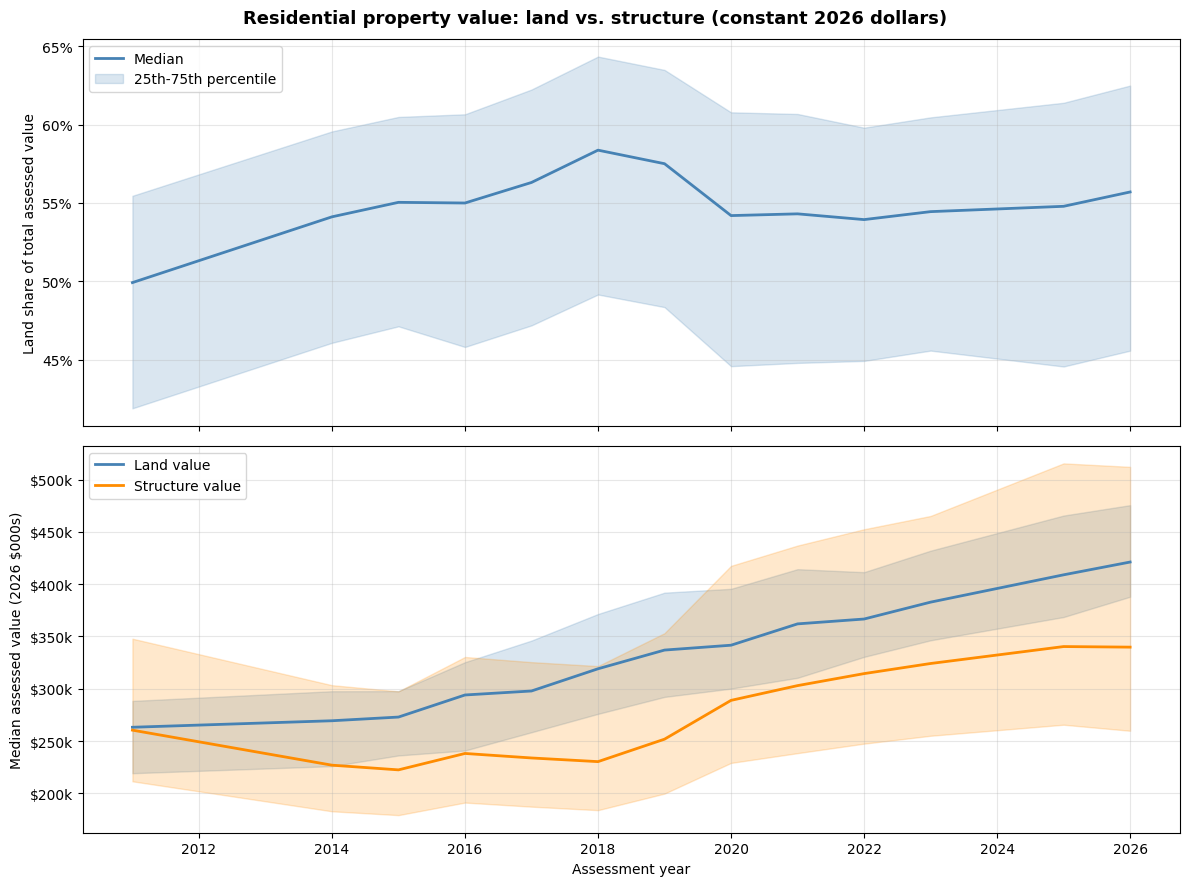

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    "Residential property value: land vs. structure (constant 2026 dollars)",
    fontsize=13,
    fontweight="bold",
)

years = stats["assessed_year"]

# Panel A: land share %
ax1.plot(years, stats["land_share_med"] * 100, color="steelblue", linewidth=2, label="Median")
ax1.fill_between(
    years,
    stats["land_share_q25"] * 100,
    stats["land_share_q75"] * 100,
    alpha=0.2,
    color="steelblue",
    label="25th-75th percentile",
)
ax1.set_ylabel("Land share of total assessed value")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax1.grid(True, alpha=0.3)
ax1.legend()

# Panel B: land and structure in constant dollars
for col, label, color in [
    ("land_val", "Land value", "steelblue"),
    ("bldg_val", "Structure value", "darkorange"),
]:
    ax2.plot(years, stats[f"{col}_med"] / 1_000, color=color, linewidth=2, label=label)
    ax2.fill_between(
        years,
        stats[f"{col}_q25"] / 1_000,
        stats[f"{col}_q75"] / 1_000,
        alpha=0.2,
        color=color,
    )

ax2.set_ylabel("Median assessed value (2026 $000s)")
ax2.set_xlabel("Assessment year")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:.0f}k"))
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Distribution of land value fractions in 2026

This plot below shows the current situation for the latest year for which data are available. It's like taking a slice of the top curve above and plotting the distribution on a histogram.

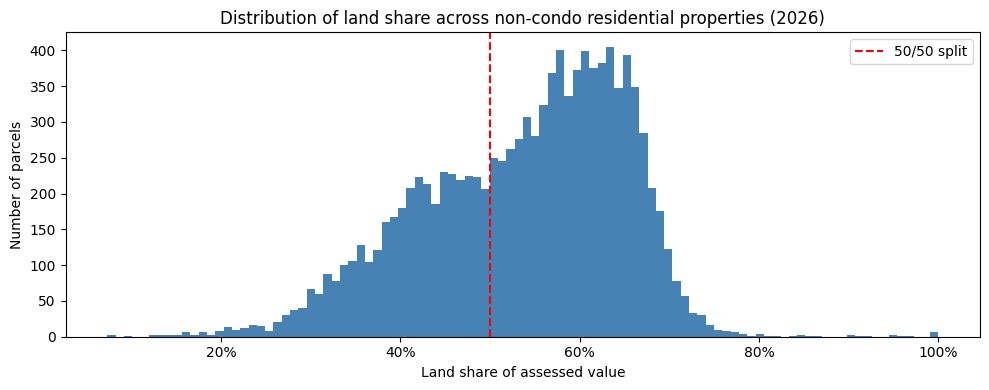

Parcels within 1pp of 50/50: 4.5%


In [15]:
latest = df[df["assessed_year"] == df["assessed_year"].max()].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latest["land_share"], bins=100, color="steelblue", edgecolor="none")
ax.axvline(0.5, color="red", linewidth=1.5, linestyle="--", label="50/50 split")
ax.set_xlabel("Land share of assessed value")
ax.set_ylabel("Number of parcels")
ax.set_title(f"Distribution of land share across non-condo residential properties ({latest['assessed_year'].iloc[0]})")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

pct_near_half = (latest["land_share"].between(0.49, 0.51)).mean()
print(f"Parcels within 1pp of 50/50: {pct_near_half:.1%}")

There's a strong peak at 60% that is clear in this graph.

# Year-on-year trend

The plot below clarifies how the median values of land and building have been evolving year on year. When one curve is higher than the other, that indicates that value
is increasing at a faster rate.

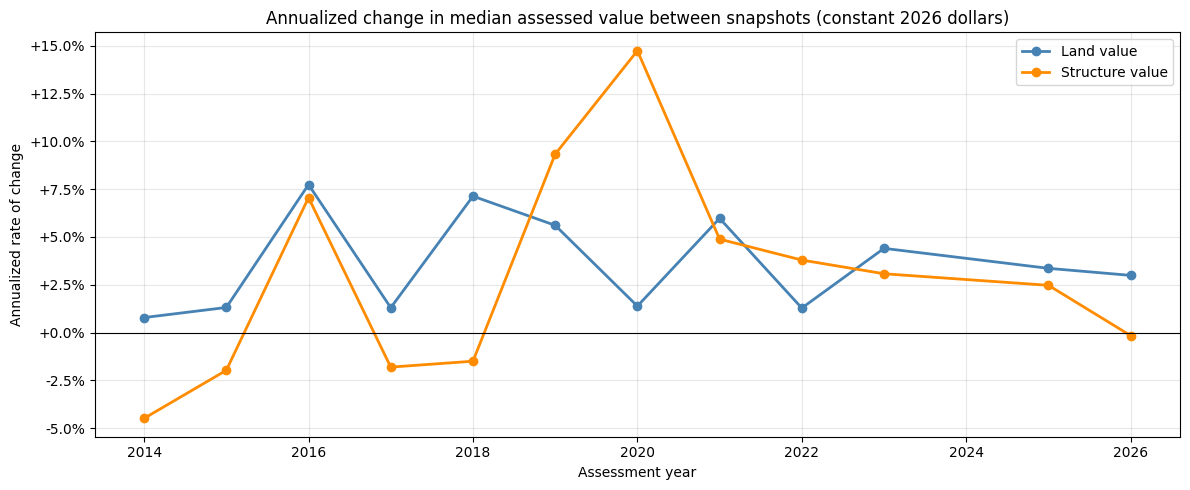

In [16]:
yoy = stats.sort_values("assessed_year").copy()
yoy["gap"] = yoy["assessed_year"].diff()
yoy["land_yoy"] = ((yoy["land_val_med"] / yoy["land_val_med"].shift(1)) ** (1 / yoy["gap"]) - 1) * 100
yoy["bldg_yoy"] = ((yoy["bldg_val_med"] / yoy["bldg_val_med"].shift(1)) ** (1 / yoy["gap"]) - 1) * 100
yoy = yoy.dropna(subset=["land_yoy"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yoy["assessed_year"], yoy["land_yoy"], color="steelblue", linewidth=2, marker="o", label="Land value")
ax.plot(yoy["assessed_year"], yoy["bldg_yoy"], color="darkorange", linewidth=2, marker="o", label="Structure value")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Annualized rate of change")
ax.set_xlabel("Assessment year")
ax.set_title("Annualized change in median assessed value between snapshots (constant 2026 dollars)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

There's an unusual spike of assessment valuations for structures being high in 2020 (noisy data in an odd year?) but for the most part land values are increasing at a higher rate than home values.

This is strong evidence that depreciation of the existing housing stock is occurring, and homebuyers are sinking a lot of capital into dirt. This is not particularly surprising, as the housing
stock of Waltham has aged to the point that the median home age is 75 years old now.